ENTRENAMIENTO CLASIFICADOR SIMPLE (2 VARIABLES)

In [1]:
import pandas as pd

# Cargar solo el Train para ver el desbalanceo
df_temp = pd.read_csv('./dataset_learning_24h.csv')
y_train_temp = df_temp[df_temp['Set_Type'] == 'Train_CV']['Target_Class']

sanos = (y_train_temp == 0).sum()
estres = (y_train_temp == 1).sum()
ratio = sanos / estres

print(f"=== ANÁLISIS DE DESBALANCEO EN TRAIN ===")
print(f"Días Sanos (Clase 0): {sanos}")
print(f"Días Estrés (Clase 1): {estres}")
print(f"Ratio de desbalanceo:  1 : {ratio:.2f}")
print(f"-> Sugerencia de rango_pesos: Rodear el valor {ratio:.2f}")

=== ANÁLISIS DE DESBALANCEO EN TRAIN ===
Días Sanos (Clase 0): 71
Días Estrés (Clase 1): 22
Ratio de desbalanceo:  1 : 3.23
-> Sugerencia de rango_pesos: Rodear el valor 3.23


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import os
import joblib

from sklearn.model_selection import RepeatedStratifiedKFold, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, recall_score, f1_score, precision_score, confusion_matrix
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from tqdm import tqdm

# ==============================================================================
# 0. GPU DETECTOR FOR XGBOOST PORTABILITY
# ==============================================================================
def get_xgb_device():
    try:
        xgb.train({'tree_method': 'hist', 'device': 'cuda'}, xgb.DMatrix(np.array([[0]]), label=np.array([0])), num_boost_round=1)
        print(" -> GPU NVIDIA detected (CUDA enabled for XGBoost)")
        return 'cuda'
    except Exception:
        print(" -> GPU not detected. Falling back to CPU.")
        return 'cpu'

XGB_DEVICE = get_xgb_device()

# ==============================================================================
# 1. SETUP & CONFIGURATION
# ==============================================================================
np.random.seed(42)  # Master Seed for pure reproducibility
OUTPUT_DIR = 'phase4_nested_cv_models'
if not os.path.exists(OUTPUT_DIR): os.makedirs(OUTPUT_DIR)

FILE_DATA = 'dataset_learning_24h.csv' 

# --- NESTED CV PARÁMETROS ---
N_SPLITS = 5        
N_REPEATS = 10      
N_ITERACIONES = N_SPLITS * N_REPEATS 

N_ITER_SEARCH = 30  # Usamos RandomizedSearch con 30 intentos aleatorios
CV_INNER_FOLDS = 3  

print(f"\n--- STARTING NESTED CROSS-VALIDATION EXPERIMENT ---")
print(f" -> Architecture: {N_SPLITS}-Fold RSKF repeated {N_REPEATS} times ({N_ITERACIONES} Outer Folds)")
print(f" -> Saving outputs to: {OUTPUT_DIR}/")

# ==============================================================================
# 2. LOAD DATA & FILTER FEATURES
# ==============================================================================
df = pd.read_csv(FILE_DATA)

# Variables Élite
elite_features = ['radiacion_sum_t0', 'HS30_min_t+1'] 
X_full = df[elite_features]
y_full = df['Target_Class']

# STRICT TEMPORAL SPLIT
idx_train = df[df['Set_Type'] == 'Train_CV'].index
X_train_cv = X_full.loc[idx_train].reset_index(drop=True)
y_train_cv = y_full.loc[idx_train].reset_index(drop=True)

print(f" -> TRAIN_CV SET (Historical Base): {X_train_cv.shape[0]} samples (Stress: {y_train_cv.sum()})")

# ==============================================================================
# 3. HYPERPARAMETER DISTRIBUTIONS (WITH SMOTE TUNING)
# ==============================================================================

# A. STANDARD LEAGUE (No Class Weights)
grid_svm_std = {
    'classifier__C': [0.01, 0.1, 1, 10, 50, 100], 
    'classifier__gamma': ['scale', 1, 0.1, 0.01, 0.001], 
    'classifier__kernel': ['rbf', 'linear']
}

grid_rf_std  = {
    'classifier__n_estimators': [50, 100, 200], 
    'classifier__max_depth': [2, 3, 4, 5], 
    'classifier__min_samples_leaf': [1, 2, 4, 6], 
    'classifier__max_features': ['sqrt', 'log2', None]
}

grid_xgb_std = {
    'classifier__n_estimators': [50, 100, 150], 
    'classifier__max_depth': [1, 2, 3],
    'classifier__learning_rate': [0.01, 0.05, 0.1], 
    'classifier__subsample': [0.7, 0.8, 1.0], 
    'classifier__colsample_bytree': [0.5, 1.0],
    'classifier__reg_lambda': [1, 5, 10]
}

# --- SMOTE TUNING --- (Lo añadiremos dinámicamente a los pipelines que lo necesiten)
smote_params = {'smote__k_neighbors': [2, 3, 5]} # 5 es el máximo seguro para tus 22 casos de estrés

# B. COST-SENSITIVE LEAGUE (With specific IR centered weights)
rango_pesos = [2.0, 3.23, 4.0, 5.0, 6.0]
pesos_grid = [{0:1, 1:w} for w in rango_pesos]

grid_svm_cost = grid_svm_std.copy()
grid_svm_cost['classifier__class_weight'] = pesos_grid

grid_rf_cost  = grid_rf_std.copy()
grid_rf_cost['classifier__class_weight'] = pesos_grid

grid_xgb_cost = grid_xgb_std.copy()
grid_xgb_cost['classifier__scale_pos_weight'] = rango_pesos

# ==============================================================================
# 4. NESTED CROSS-VALIDATION LOOP
# ==============================================================================
results_all = []
candidates = {
    'Baseline': {'SVM': [], 'RF': [], 'XGB': []},
    'SMOTE only': {'SVM': [], 'RF': [], 'XGB': []},
    'Cost-Sensitive': {'SVM': [], 'RF': [], 'XGB': []},
    'Hybrid (SMOTE+Cost)': {'SVM': [], 'RF': [], 'XGB': []}
}

rskf = RepeatedStratifiedKFold(n_splits=N_SPLITS, n_repeats=N_REPEATS, random_state=42)

for i, (train_idx, val_idx) in enumerate(tqdm(rskf.split(X_train_cv, y_train_cv), total=N_ITERACIONES, desc="Nested CV Loop")):
    
    X_t, y_t = X_train_cv.iloc[train_idx], y_train_cv.iloc[train_idx]
    X_v, y_v = X_train_cv.iloc[val_idx], y_train_cv.iloc[val_idx]
    
    pipes_base = {
        'SVM': ImbPipeline([('scaler', StandardScaler()), ('classifier', SVC(probability=True, random_state=i))]),
        'RF':  ImbPipeline([('scaler', StandardScaler()), ('classifier', RandomForestClassifier(random_state=i))]),
        'XGB': ImbPipeline([('scaler', StandardScaler()), ('classifier', xgb.XGBClassifier(eval_metric='logloss', tree_method='hist', device=XGB_DEVICE, random_state=i))])
    }
    
    # SMOTE base init, los hyperparámetros se pisarán con el Grid
    pipes_smote = {
        'SVM': ImbPipeline([('smote', SMOTE(random_state=i)), ('scaler', StandardScaler()), ('classifier', SVC(probability=True, random_state=i))]),
        'RF':  ImbPipeline([('smote', SMOTE(random_state=i)), ('scaler', StandardScaler()), ('classifier', RandomForestClassifier(random_state=i))]),
        'XGB': ImbPipeline([('smote', SMOTE(random_state=i)), ('scaler', StandardScaler()), ('classifier', xgb.XGBClassifier(eval_metric='logloss', tree_method='hist', device=XGB_DEVICE, random_state=i))])
    }

    configs = [
        ('Baseline', pipes_base, grid_svm_std, grid_rf_std, grid_xgb_std, False), 
        ('SMOTE only', pipes_smote, grid_svm_std, grid_rf_std, grid_xgb_std, True),
        ('Cost-Sensitive', pipes_base, grid_svm_cost, grid_rf_cost, grid_xgb_cost, False),
        ('Hybrid (SMOTE+Cost)', pipes_smote, grid_svm_cost, grid_rf_cost, grid_xgb_cost, True)
    ]
    
    for mode, pipes, g_svm, g_rf, g_xgb, use_smote in configs:
        
        # Inyectar los parámetros de SMOTE si toca
        if use_smote:
            g_svm = {**g_svm, **smote_params}
            g_rf = {**g_rf, **smote_params}
            g_xgb = {**g_xgb, **smote_params}
            
        grids_map = {'SVM': g_svm, 'RF': g_rf, 'XGB': g_xgb}
        
        for model_name, pipeline in pipes.items():
            
            # INNER LOOP (Search)
            search = RandomizedSearchCV(
                estimator=pipeline, 
                param_distributions=grids_map[model_name], 
                n_iter=N_ITER_SEARCH, 
                cv=StratifiedKFold(n_splits=CV_INNER_FOLDS, shuffle=True, random_state=i), 
                scoring='f1', 
                n_jobs=-1,
                random_state=i
            )
            search.fit(X_t, y_t)
            best_fold_model = search.best_estimator_
            
            # OUTER LOOP (Evaluation)
            preds_val = best_fold_model.predict(X_v)
            
            met = {
                'Accuracy': accuracy_score(y_v, preds_val),
                'Recall': recall_score(y_v, preds_val, pos_label=1, zero_division=0),
                'Precision': precision_score(y_v, preds_val, pos_label=1, zero_division=0),
                'F1': f1_score(y_v, preds_val, pos_label=1, zero_division=0)
            }
            
            results_all.append({'Iteration': i, 'Mode': mode, 'Model': model_name, **met})
            cm = confusion_matrix(y_v, preds_val, labels=[1, 0])
            
            candidates[mode][model_name].append({
                'params': search.best_params_, 'metrics': met, 'cm': cm, 'iter': i, 'best_model': best_fold_model
            })

# ==============================================================================
# 5. SELECT MEDIAN PARAMS, RETRAIN FINAL MODELS & SAVE
# ==============================================================================
print("\n--- EXTRACTING MEDIAN HYPERPARAMETERS & RETRAINING FULL TRAIN_CV ---")
median_params_summary = []
median_cm_data = {mode: {} for mode in candidates.keys()}

for mode in candidates.keys():
    for model_name in ['SVM', 'RF', 'XGB']:
        runs = candidates[mode][model_name]
        runs_sorted = sorted(runs, key=lambda x: x['metrics']['F1'])
        median_run = runs_sorted[len(runs_sorted)//2] 
        
        median_cm_data[mode][model_name] = median_run['cm']
        
        # En lugar de reconstruir el pipeline a mano (que es propenso a errores), 
        # cogemos el mejor pipeline ya construido por RandomizedSearch y lo reentrenamos con todo el Train
        final_pipe = median_run['best_model']
        final_pipe.fit(X_train_cv, y_train_cv)
        
        # Guardar modelo de producción
        safe_mode = mode.replace(' ', '_').replace('+', 'plus').replace('(', '').replace(')', '')
        filename = f"model_{safe_mode}_{model_name}_final.pkl"
        joblib.dump(final_pipe, os.path.join(OUTPUT_DIR, filename))
        
        # Extraemos los mejores hiperparámetros de ese caso mediano para el CSV
        best_params = median_run['params']
        clean_params = {k.replace('classifier__', '').replace('smote__', ''): v for k, v in best_params.items()}
        
        median_params_summary.append({
            'Mode': mode, 'Model': model_name,
            'Best_Params': str(clean_params), 'Median_F1_Val': median_run['metrics']['F1']
        })

df_params = pd.DataFrame(median_params_summary)
df_params.to_csv(f"{OUTPUT_DIR}/median_models_parameters.csv", index=False)

# ==============================================================================
# 6. VISUALIZATION (Q1 GRAPHS)
# ==============================================================================
df_results = pd.DataFrame(results_all)
summary = df_results.groupby(['Mode', 'Model'])[['Accuracy', 'Recall', 'Precision', 'F1']].agg(['mean', 'std'])
summary.to_csv(f"{OUTPUT_DIR}/metrics_summary_table.csv")

# A. BOXPLOTS 
print("\n -> Generating Comparative Boxplots...")
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(22, 7))

metrics_to_plot = ['Precision', 'Recall', 'F1']
titles = ['Precision', 'Recall', 'F1-Score']

colors = {
    'Baseline': '#999999',              
    'SMOTE only': '#1f78b4',            
    'Cost-Sensitive': '#e31a1c',        
    'Hybrid (SMOTE+Cost)': '#984ea3'    
}

for idx, metric in enumerate(metrics_to_plot):
    sns.boxplot(
        data=df_results, x='Model', y=metric, hue='Mode', 
        palette=colors, showmeans=True,
        meanprops={"marker":"o", "markerfacecolor":"black", "markeredgecolor":"black", "markersize": "7"},
        ax=axes[idx]
    )
    axes[idx].set_title(titles[idx], fontsize=18, fontweight='bold', pad=15)
    axes[idx].set_ylim(-0.05, 1.05)
    axes[idx].set_ylabel(metric, fontsize=15)
    axes[idx].set_xlabel("Model Architecture", fontsize=15)
    axes[idx].tick_params(axis='both', which='major', labelsize=13)
    
    if idx == 0:
        axes[idx].legend(loc='lower left', fontsize=11, framealpha=0.9, title="Imbalance Strategy")
    else:
        axes[idx].get_legend().remove()

plt.suptitle(f"Nested Cross-Validation Benchmark (5x10 Folds)", fontsize=22, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/comparative_boxplots_4way.png", dpi=300, bbox_inches='tight')
plt.close()

# B. CONFUSION MATRICES (Median Fold)
print(" -> Generating Confusion Matrices (Median Cases)...")
global_max = np.max([median_cm_data[mode][m] for mode in median_cm_data for m in median_cm_data[mode]])

def plot_cm_row(mode_name, cm_dict, cmap, filename):
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    for idx, model in enumerate(['SVM', 'RF', 'XGB']):
        cm = cm_dict[model]
        sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=axes[idx], 
                    annot_kws={"size": 26, "weight": "bold"},
                    vmin=0, vmax=global_max, cbar=idx==2) 
        axes[idx].set_title(f"{model}", fontsize=22, fontweight='bold', pad=15)
        axes[idx].set_xlabel('Predicted Label', fontsize=18)
        if idx == 0: axes[idx].set_ylabel('True Label', fontsize=18)
        else: axes[idx].set_ylabel('')
        axes[idx].set_xticklabels(['Stress', 'Healthy'], fontsize=16)
        axes[idx].set_yticklabels(['Stress', 'Healthy'], fontsize=16, rotation=0)

    plt.suptitle(f"Confusion Matrices (Median Fold Performance) - {mode_name}", fontsize=24, y=1.05)
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/{filename}", dpi=300, bbox_inches='tight')
    plt.close()

plot_cm_row("Baseline (No Balancing)", median_cm_data['Baseline'], 'Greys', "CM_Baseline.png")
plot_cm_row("SMOTE only", median_cm_data['SMOTE only'], 'Blues', "CM_SMOTE.png")
plot_cm_row("Cost-Sensitive only", median_cm_data['Cost-Sensitive'], 'Reds', "CM_Cost.png")
plot_cm_row("Hybrid (SMOTE + Cost)", median_cm_data['Hybrid (SMOTE+Cost)'], 'Purples', "CM_Hybrid.png")

print("\n" + "="*80)
print(" NESTED CROSS-VALIDATION EXPERIMENT COMPLETED")
print(" Final models retrained on 100% Train_CV and saved as .pkl")
print("="*80)

C:\Users\Iratxe\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\xgboost\training.py:200: UserWarning: [19:13:57] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\context.cc:53: No visible GPU is found, setting device to CPU.
  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\Iratxe\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\xgboost\training.py:200: UserWarning: [19:13:57] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  bst.update(dtrain, iteration=i, fobj=obj)


 -> GPU NVIDIA detected (CUDA enabled for XGBoost)

--- STARTING NESTED CROSS-VALIDATION EXPERIMENT ---
 -> Architecture: 5-Fold RSKF repeated 10 times (50 Outer Folds)
 -> Saving outputs to: phase4_nested_cv_models/
 -> TRAIN_CV SET (Historical Base): 93 samples (Stress: 22)


Nested CV Loop:   0%|          | 0/50 [00:00<?, ?it/s]C:\Users\Iratxe\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\xgboost\training.py:200: UserWarning: [19:14:04] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\context.cc:53: No visible GPU is found, setting device to CPU.
  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\Iratxe\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\xgboost\training.py:200: UserWarning: [19:14:04] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\Iratxe\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\xgboost\training.py:200: UserWarning: [19:14:06] WARNING: C:\actions


--- EXTRACTING MEDIAN HYPERPARAMETERS & RETRAINING FULL TRAIN_CV ---


C:\Users\Iratxe\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\xgboost\training.py:200: UserWarning: [19:23:52] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\context.cc:53: No visible GPU is found, setting device to CPU.
  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\Iratxe\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\xgboost\training.py:200: UserWarning: [19:23:52] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\Iratxe\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\xgboost\training.py:200: UserWarning: [19:23:52] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\context.cc:53: No vi


 -> Generating Comparative Boxplots...
 -> Generating Confusion Matrices (Median Cases)...

 NESTED CROSS-VALIDATION EXPERIMENT COMPLETED
 Final models retrained on 100% Train_CV and saved as .pkl


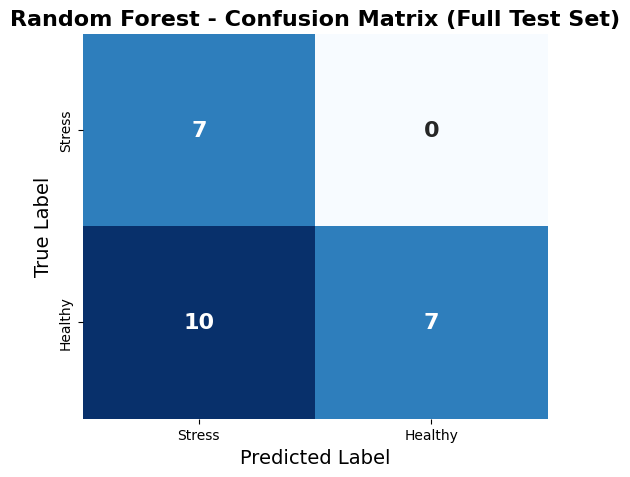

In [3]:
import pandas as pd
import joblib
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Cargar modelo final
final_rf_model = joblib.load('./phase4_nested_cv_models/model_Hybrid_SMOTEplusCost_RF_final.pkl')

# 2. Cargar dataset y filtrar Test_Temporal
df = pd.read_csv('./dataset_learning_24h.csv')
X_test = df[df['Set_Type']=='Test_Temporal'][['radiacion_sum_t0', 'HS30_min_t+1']].reset_index(drop=True)
y_test = df[df['Set_Type']=='Test_Temporal']['Target_Class'].reset_index(drop=True)

# 3. Predecir
y_pred = final_rf_model.predict(X_test)

# 4. Matriz de confusión completa
cm = confusion_matrix(y_test, y_pred, labels=[1,0])  # [1=Stress, 0=Healthy]

# 5. Graficar
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Stress', 'Healthy'], yticklabels=['Stress', 'Healthy'],
            cbar=False, annot_kws={"size":16, "weight":"bold"})
plt.xlabel("Predicted Label", fontsize=14)
plt.ylabel("True Label", fontsize=14)
plt.title("Random Forest - Confusion Matrix (Full Test Set)", fontsize=16, fontweight='bold')
plt.show()